Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone One, create a Jupyter Notebook (similar to in Module B, semester two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data using the methods you have learned about in this course and in this program and draw interesting conclusions. 

For Week 4, include concepts such as logistic regression and feature scaling. This homework should be submitted for peer review in the assignment titled 4.3 Peer Review: Week 4 Jupyter Notebook. Complete and submit your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In Week 7, you will compile your findings from your Jupyter Notebook homework into your Milestone One assignment for grading. For full instructions and the rubric for Milestone One, refer to the following link. 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/jamieconner/projects/bu/dx799_01/mod_c_capstone


### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from src.load_data import load_wisconsin, load_brazil, split_X_y

In [3]:
def evaluate_binary_model(name, y_true, y_pred, y_score=None):
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    
    if y_score is not None:
        row["roc_auc"] = roc_auc_score(y_true, y_score)
        row["pr_auc"] = average_precision_score(y_true, y_score)
    
    return row

In [4]:
df_w, target_w = load_wisconsin()
X_w, y_w = split_X_y(df_w, target_w)



Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_w,
    y_w,
    test_size=0.2,
    random_state=42,
    stratify=y_w
)


In [5]:
wisconsin_models = {
    "Wisconsin Logistic Unscaled": Pipeline([
        ("model", LogisticRegression(max_iter=10000, random_state=42))
    ]),
    
    "Wisconsin Logistic Scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=10000, random_state=42))
    ])
}

wisconsin_results = []

for name, model in wisconsin_models.items():
    model.fit(Xw_train, yw_train)
    
    y_pred = model.predict(Xw_test)
    y_score = model.predict_proba(Xw_test)[:, 1]
    
    wisconsin_results.append(evaluate_binary_model(name, yw_test, y_pred, y_score))

wisconsin_results_df = pd.DataFrame(wisconsin_results)
wisconsin_results_df


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Wisconsin Logistic Unscaled,0.938596,0.972973,0.857143,0.911392,0.992394,0.986931
1,Wisconsin Logistic Scaled,0.964912,0.975000,0.928571,0.951220,0.996032,0.994274


In [6]:
df_b, target_b = load_brazil(sample_size=100000, random_state=42)
X_b, y_b = split_X_y(df_b, target_b)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_b,
    y_b,
    test_size=0.2,
    random_state=42,
    stratify=y_b
)

In [7]:
brazil_models = {
    "Brazil Logistic Scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=10000, random_state=42))
    ]),
    
    "Brazil Logistic Scaled Balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=10000,
            random_state=42,
            class_weight="balanced"
        ))
    ])
}

brazil_results = []

for name, model in brazil_models.items():
    model.fit(Xb_train, yb_train)
    
    y_pred = model.predict(Xb_test)
    y_score = model.predict_proba(Xb_test)[:, 1]
    
    brazil_results.append(evaluate_binary_model(name, yb_test, y_pred, y_score))

brazil_results_df = pd.DataFrame(brazil_results)
brazil_results_df


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Brazil Logistic Scaled,0.94425,0.682741,0.383464,0.491100,0.938624,0.498608
1,Brazil Logistic Scaled Balanced,0.84420,0.299085,0.908767,0.450053,0.940950,0.479120


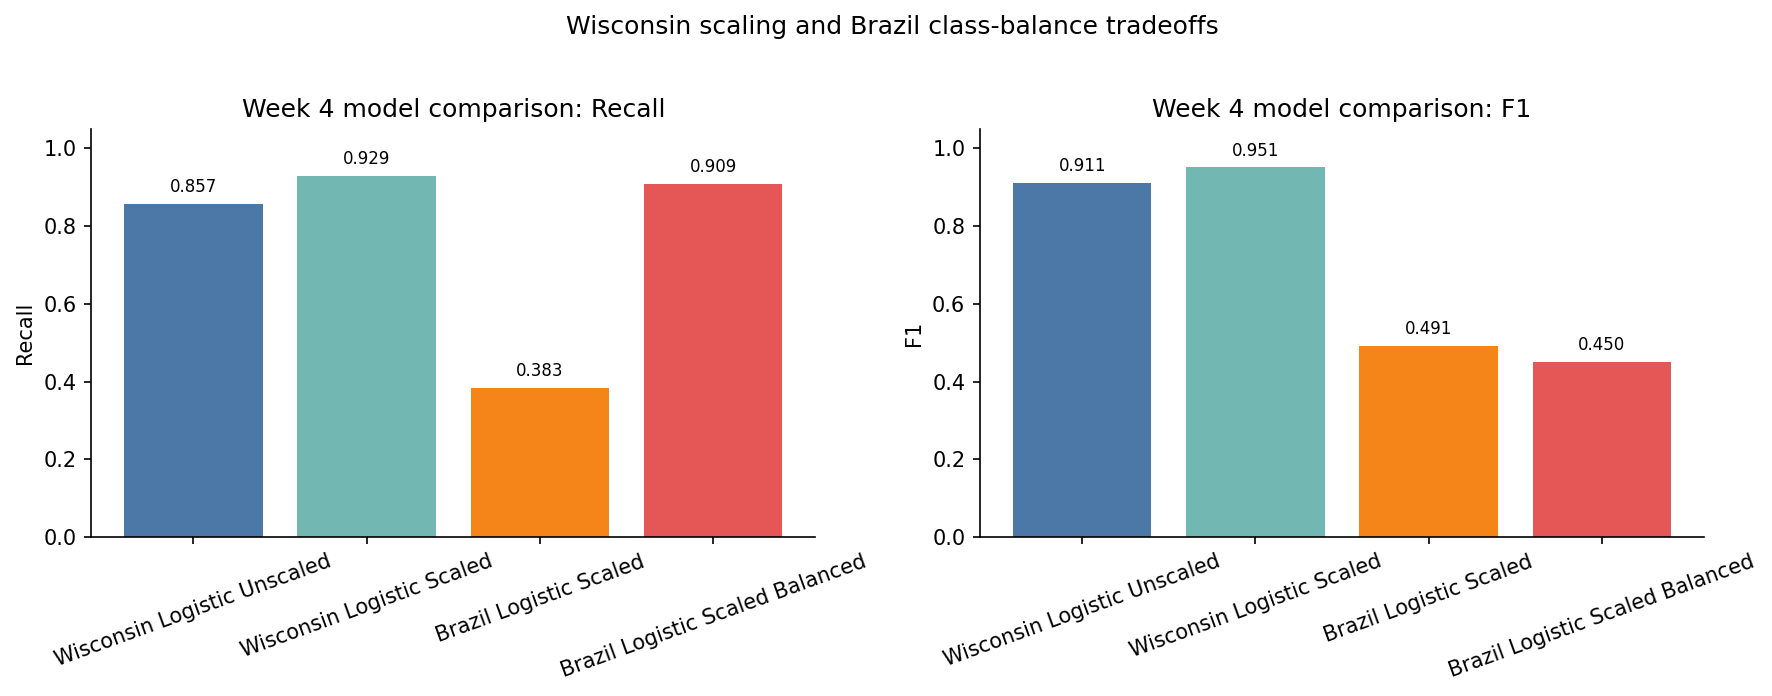

In [8]:
comparison_df = pd.concat([wisconsin_results_df, brazil_results_df], ignore_index=True)
comparison_order = [
    "Wisconsin Logistic Unscaled",
    "Wisconsin Logistic Scaled",
    "Brazil Logistic Scaled",
    "Brazil Logistic Scaled Balanced",
]
comparison_df = comparison_df.set_index("model").loc[comparison_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)
metrics = [("recall", "Recall"), ("f1", "F1")]
colors = ["#4C78A8", "#72B7B2", "#F58518", "#E45756"]

for ax, (metric_key, metric_label) in zip(axes, metrics):
    bars = ax.bar(comparison_df["model"], comparison_df[metric_key], color=colors)
    ax.set_title(f"Week 4 model comparison: {metric_label}")
    ax.set_ylabel(metric_label)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
    for bar, value in zip(bars, comparison_df[metric_key]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.3f}", ha="center", va="bottom", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Wisconsin scaling and Brazil class-balance tradeoffs", y=1.02)
fig.tight_layout()
plt.show()


In [9]:
best_brazil_logreg = brazil_models["Brazil Logistic Scaled Balanced"]
best_brazil_logreg.fit(Xb_train, yb_train)

yb_score = best_brazil_logreg.predict_proba(Xb_test)[:, 1]

In [10]:
thresholds = np.arange(0.05, 0.96, 0.05)

threshold_rows = []

for threshold in thresholds:
    y_pred_thresh = (yb_score >= threshold).astype(int)
    
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(yb_test, y_pred_thresh, zero_division=0),
        "recall": recall_score(yb_test, y_pred_thresh, zero_division=0),
        "f1": f1_score(yb_test, y_pred_thresh, zero_division=0),
        "accuracy": accuracy_score(yb_test, y_pred_thresh),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.head()

,threshold,precision,recall,f1,accuracy
0,0.05,0.128492,1.000000,0.227723,0.52420
1,0.10,0.148968,0.997862,0.259235,0.59995
2,0.15,0.178013,0.982181,0.301400,0.68060
3,0.20,0.204852,0.975053,0.338572,0.73275
4,0.25,0.220845,0.965075,0.359437,0.75870


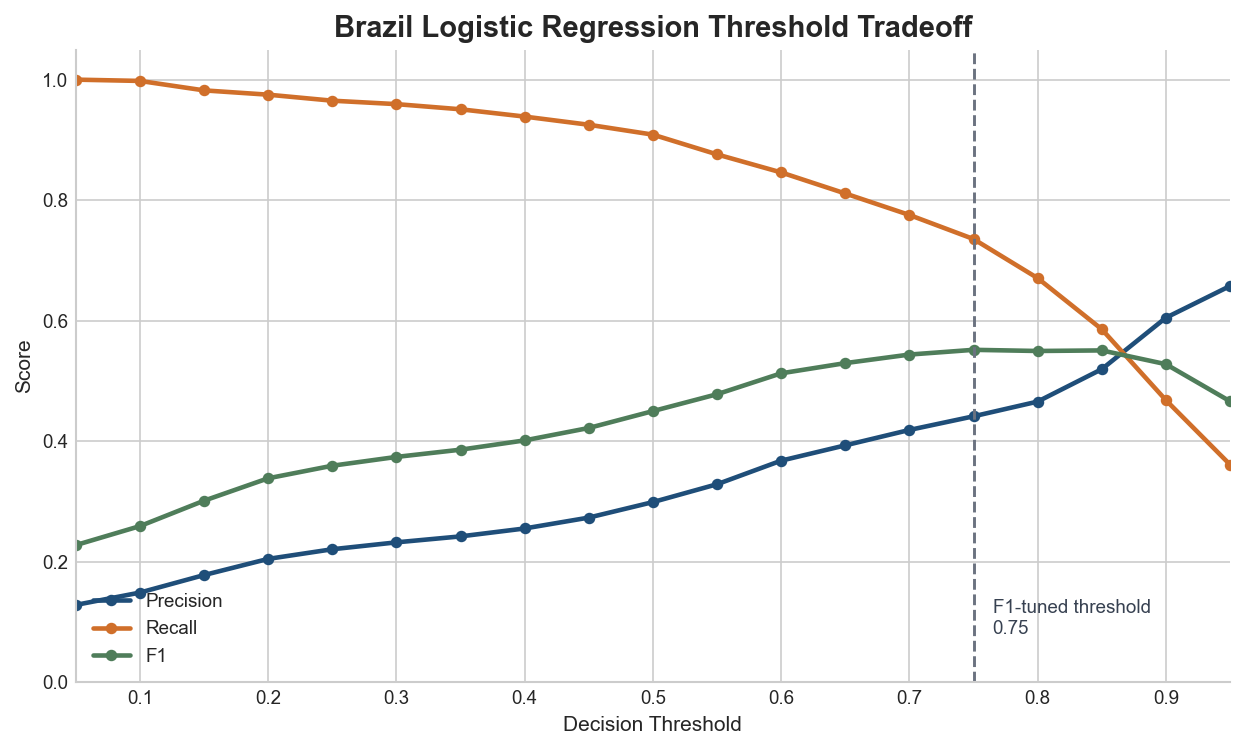

In [11]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "milestone1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]

fig, ax = plt.subplots(figsize=(8.4, 5.1))

line_specs = [
    ("precision", "Precision", "#1F4E79"),
    ("recall", "Recall", "#D06F2A"),
    ("f1", "F1", "#4F7D5A"),
]
for metric, label, color in line_specs:
    ax.plot(threshold_df["threshold"], threshold_df[metric], marker="o", linewidth=2.2, markersize=4.5, label=label, color=color)

best_threshold = float(best_f1_row["threshold"])
ax.axvline(best_threshold, color="#6B7280", linestyle="--", linewidth=1.4)
ax.text(best_threshold + 0.015, 0.08, f"F1-tuned threshold\n{best_threshold:.2f}", color="#374151", fontsize=9)

ax.set_title("Brazil Logistic Regression Threshold Tradeoff", fontsize=14, weight="bold")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xlim(threshold_df["threshold"].min(), threshold_df["threshold"].max())
ax.legend(frameon=False, loc="lower left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig04_brazil_threshold_tradeoff.png", bbox_inches="tight", facecolor="white")
plt.show()


In [12]:
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_f1_row

threshold    0.750000
precision    0.441403
recall       0.735567
f1           0.551724
accuracy     0.916150
Name: 14, dtype: float64

In [13]:
recall_target =  0.735567

high_recall_options = threshold_df[threshold_df["recall"] >= recall_target]

if len(high_recall_options) > 0:
    best_high_recall = high_recall_options.sort_values("precision", ascending=False).iloc[0]
    print(best_high_recall)
else:
    print("No threshold achieved the recall target.")

threshold    0.700000
precision    0.418784
recall       0.775481
f1           0.543864
accuracy     0.908750
Name: 13, dtype: float64


In [14]:
default_pred = (yb_score >= 0.50).astype(int)

best_threshold = best_f1_row["threshold"]
tuned_pred = (yb_score >= best_threshold).astype(int)

print("Default threshold confusion matrix:")
print(confusion_matrix(yb_test, default_pred))

print("\nTuned threshold confusion matrix:")
print(confusion_matrix(yb_test, tuned_pred))

print("\nDefault threshold report:")
print(classification_report(yb_test, default_pred, zero_division=0))

print("\nTuned threshold report:")
print(classification_report(yb_test, tuned_pred, zero_division=0))

Default threshold confusion matrix:
[[15609  2988]
 [  128  1275]]

Tuned threshold confusion matrix:
[[17291  1306]
 [  371  1032]]

Default threshold report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     18597
           1       0.30      0.91      0.45      1403

    accuracy                           0.84     20000
   macro avg       0.65      0.87      0.68     20000
weighted avg       0.94      0.84      0.88     20000


Tuned threshold report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     18597
           1       0.44      0.74      0.55      1403

    accuracy                           0.92     20000
   macro avg       0.71      0.83      0.75     20000
weighted avg       0.94      0.92      0.93     20000



This Week 4 notebook applied logistic regression and feature scaling to the Wisconsin and Brazil cancer datasets in preparation for Milestone 1. For Wisconsin, scaling improved logistic regression performance, raising accuracy from about 0.94 to 0.96 and recall from about 0.86 to 0.93. This supports the earlier conclusion that Wisconsin is a clean, highly separable benchmark dataset, but also shows that scaling still matters for logistic regression because the model is sensitive to feature scale.

The Brazil analysis was more important for the overall Milestone 1 story because it showed how model evaluation changes under class imbalance. The standard scaled logistic regression had higher accuracy, but the balanced model greatly improved recall for the positive class. Threshold tuning then showed the tradeoff clearly: the default threshold caught more positive cases, while the tuned threshold improved precision, F1, and overall accuracy at the cost of lower recall. This directly supports the project’s diagnostic workflow theme: model quality should not be judged by accuracy alone, especially when false negatives carry clinical risk.
